# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
path_xgboost = os.path.join(MODEL, "XGBoost_Fine_Tune_40")
path_xgboost_rubin = os.path.join(MODEL, "Tune_XGBoost_Rubin_7DT_40")

model_pickles_dict = {
    # "7DT-only": os.path.join(path_xgboost, "best_params_n100.yaml"),
    "7DT+u": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubinu_n100.pkl"),
    "7DT+g": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubing_n100.pkl"),
    "7DT+r": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubinr_n100.pkl"),
    "7DT+i": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubini_n100.pkl"),
    "7DT+z": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubinz_n100.pkl"),
    "7DT+y": os.path.join(path_xgboost_rubin, "xgboost_7DT_rubiny_n100.pkl"),
}

model_params_dict = {
    # "7DT-only": os.path.join(path_xgboost, "best_params_n100.yaml"),
    "7DT+u": os.path.join(path_xgboost_rubin, "best_params_rubinu_n100.yaml"),
    "7DT+g": os.path.join(path_xgboost_rubin, "best_params_rubing_n100.yaml"),
    "7DT+r": os.path.join(path_xgboost_rubin, "best_params_rubinr_n100.yaml"),
    "7DT+i": os.path.join(path_xgboost_rubin, "best_params_rubini_n100.yaml"),
    "7DT+z": os.path.join(path_xgboost_rubin, "best_params_rubinz_n100.yaml"),
    "7DT+y": os.path.join(path_xgboost_rubin, "best_params_rubiny_n100.yaml"),
}

model_pickles_dict

{'7DT+u': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubinu_n100.pkl',
 '7DT+g': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubing_n100.pkl',
 '7DT+r': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubinr_n100.pkl',
 '7DT+i': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubini_n100.pkl',
 '7DT+z': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubinz_n100.pkl',
 '7DT+y': '/home/gpaek/SED-Classifier/notebook/../model/Tune_XGBoost_Rubin_7DT_40/xgboost_7DT_rubiny_n100.pkl'}

In [10]:
# Set experiment configs
test_name = "Feature_Selection_XGBoost_Rubin_7DT"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"

- Source to Consider

In [11]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	# "LBV", 
	"TDE", 
	# "Nova", 
	# "M dwarf", 
	# "CV",
	"SLSN",
    "SV",
    "Asteroid",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [12]:
path_data = os.path.join(FEATURE_NEW_DATA, 'features_40_rubin_7dt_color_only.csv')

logtxt += f"\nBalanced Data Set\n"

In [13]:
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

# Data

In [14]:
# columns_to_use = list(data_dtype_dict.keys())

In [23]:
data = pd.read_csv(
    path_data,
    engine='c', 
    # usecols=columns_to_use,
    dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 80605
8 sources to consider: 80605


In [30]:
key0 = "r-m800"
key1 = "m400-y"

if key0 in data.keys():
    print(key0, "exists")
if key1 in data.keys():
    print(key1, "exists")

# for key in data.keys():
#     print(key)

r-m800 exists
m400-y exists


- Training and Test Data

In [17]:
# - Split features/target
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
X.fillna(-99, inplace=True)
y = data['Class']
uids = data['uid']


# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

from catboost import CatBoostClassifier, Pool

# - Label encode class for ML
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_encoded = label_encoder.transform(y)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)


Balanced: Class mapping: ['AGN' 'Asteroid' 'II' 'Ia' 'Ibc' 'SLSN' 'SV' 'TDE']


- Train data for each model 

In [18]:
import xgboost as xgb
train_data_xgb = xgb.DMatrix(X_train, label=y_train_encoded)
test_data_xgb = xgb.DMatrix(X_test, label=y_test_encoded)

In [19]:
# del data

In [32]:
lsst_filters = ['u', 'g', 'r', 'i', 'z', 'y']

lsst_filter = lsst_filters[0]

sub_feature_dict = {}

for lsst_filter in lsst_filters:
    features_to_use = []
    for key in X_train.keys():
        if (lsst_filter in key) | (key.count('m') == 2):
            # print(key)
            features_to_use.append(key)
    sub_feature_dict[lsst_filter] = features_to_use
    print(f"{lsst_filter}-BAND: {len(features_to_use)}")

u-BAND: 820
g-BAND: 820
r-BAND: 820
i-BAND: 820
z-BAND: 820
y-BAND: 820


# Model

In [20]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from xgboost.callback import EarlyStopping


from xgboost import XGBClassifier


- Load Models

In [40]:
import pickle
import joblib

model_dict = {}
for model_name, pickle_name in model_pickles_dict.items():
    print(f"MODEL NAME: {model_name}")
    
    filte = model_name.split("+")[-1]
    features = sub_feature_dict[filte]

    test_data_xgb = xgb.DMatrix(X_test[features], label=y_test_encoded)
    
    model = joblib.load(pickle_name)
    prob = model.predict(test_data_xgb)
    y_pred = np.argmax(prob, axis=1)

    
    model_dict[model_name] = {
        "model": model,
        "prob": prob,
        "y_pred": y_pred,
    }

MODEL NAME: 7DT+u
MODEL NAME: 7DT+g
MODEL NAME: 7DT+r
MODEL NAME: 7DT+i
MODEL NAME: 7DT+z
MODEL NAME: 7DT+y


In [42]:
from sklearn.metrics import classification_report

def get_report_df(y_true, y_pred, label_encoder, digits=3):
    report_dict = classification_report(
        y_true, y_pred, target_names=label_encoder.classes_, output_dict=True
    )
    return pd.DataFrame(report_dict).T.round(digits)



In [44]:
for model_name, pickle_name in model_pickles_dict.items():
    print(f"MODEL NAME: {model_name}")

    info_dict = model_dict[model_name]

    y_pred = info_dict["y_pred"]

    df = get_report_df(y_test_encoded, y_pred, label_encoder)
    info_dict['df'] = df
    model_dict[model_name] = info_dict

df

MODEL NAME: 7DT+u
MODEL NAME: 7DT+g
MODEL NAME: 7DT+r
MODEL NAME: 7DT+i
MODEL NAME: 7DT+z
MODEL NAME: 7DT+y


,precision,recall,f1-score,support
AGN,0.793,0.840,0.815,1260.000
Asteroid,0.912,0.985,0.947,1965.000
II,0.747,0.862,0.800,2196.000
Ia,0.884,0.910,0.897,2056.000
Ibc,0.822,0.765,0.792,1885.000
SLSN,0.920,0.669,0.775,1464.000
SV,0.820,0.835,0.827,2046.000
TDE,0.881,0.823,0.851,2106.000
accuracy,0.843,0.843,0.843,0.843
macro avg,0.847,0.836,0.838,14978.000


In [47]:
# 모델 이름과 고정 색상 매핑
model_colors = {
    "7DT+u": "#1f77b4",        # 파랑
    "7DT+g": "#ff7f0e",         # 주황
    "7DT+r": "#2ca02c",        # 녹색
    "7DT+i": "#d62728",        # 빨강
    "7DT+z": "#9467bd",    # 보라
    "7DT+y": "#8c564b",   # 갈색
}

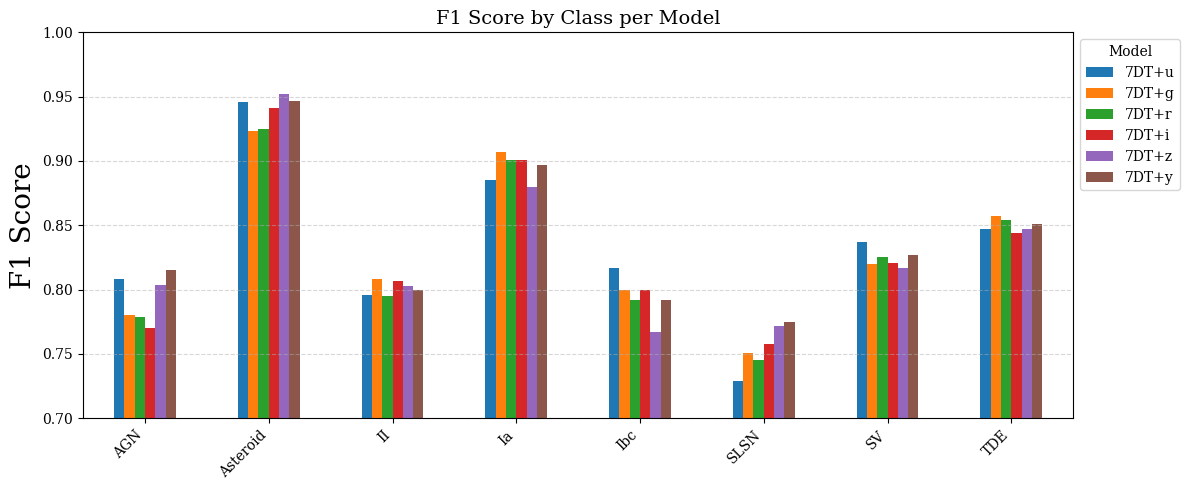

In [48]:
# reports 딕셔너리 구성
reports = {model: info["df"] for model, info in model_dict.items()}

# 클래스 이름 필터링
class_names = [label for label in reports[list(reports.keys())[0]].index
               if label not in ['accuracy', 'macro avg', 'weighted avg']]

# 각 모델별 f1-score 수집
f1_scores_by_class = pd.DataFrame({
    model: df.loc[class_names, "f1-score"]
    for model, df in reports.items()
}, index=class_names)

# 색상 지정 (모델 순서를 f1_scores_by_class.columns 기준으로)
color_list = [model_colors.get(model, "#999999") for model in f1_scores_by_class.columns]

# 시각화
f1_scores_by_class.plot(kind='bar', figsize=(12, 5), color=color_list)
plt.title("F1 Score by Class per Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.70, 1.0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Model', bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()


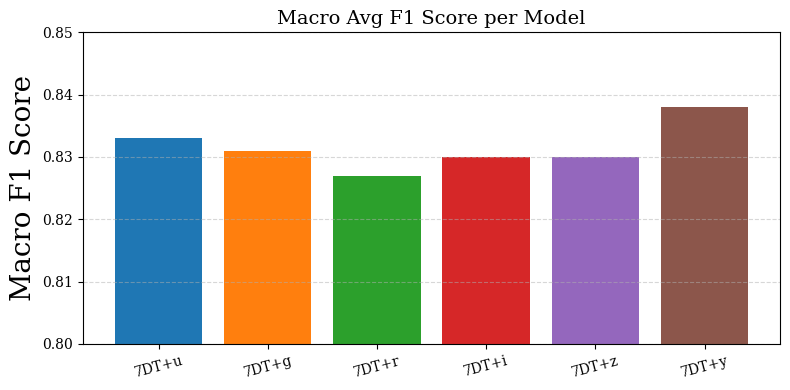

In [49]:
# macro f1 score 추출
macro_f1_scores = {
    model: df.loc["macro avg", "f1-score"]
    for model, df in reports.items()
}

# 색상 리스트
color_list = [model_colors[model] for model in macro_f1_scores.keys()]

# 시각화
plt.figure(figsize=(8, 4))
plt.bar(macro_f1_scores.keys(), macro_f1_scores.values(), color=color_list)
plt.title("Macro Avg F1 Score per Model")
plt.ylabel("Macro F1 Score")
plt.ylim(0.8, 0.85)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

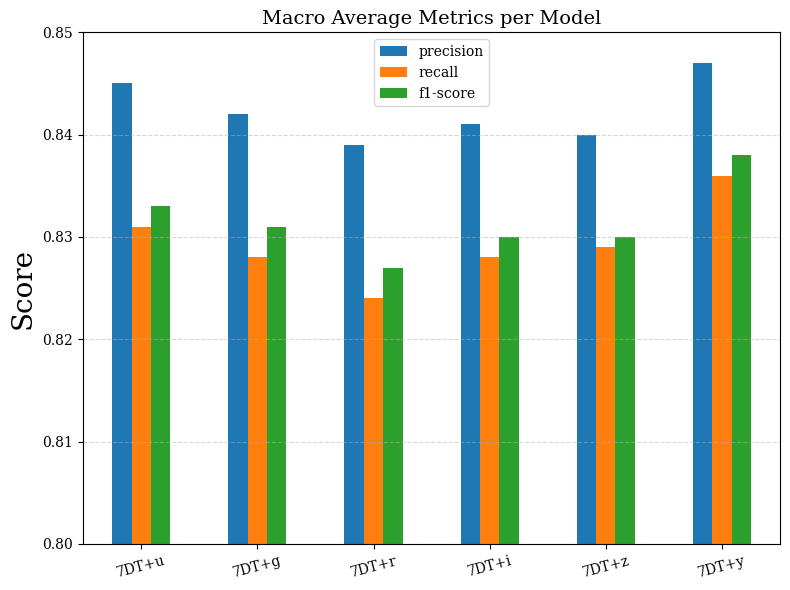

In [50]:
# macro 평균 precision, recall, f1 추출
macro_metrics = pd.DataFrame({
    model: df.loc["macro avg", ["precision", "recall", "f1-score"]]
    for model, df in reports.items()
}).T

# 시각화
ax = macro_metrics.plot(kind="bar", figsize=(8, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])  # 기본 3색
plt.title("Macro Average Metrics per Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.8, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Feature Importance

## Mean Feature Importance

In [51]:
# # 다중 클래스 shap_values (list of arrays) 처리
# def compute_importance(shap_values):
#     if isinstance(shap_values, list):
#         # shape: (n_classes, n_features), 평균 across classes
#         return np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
#     else:
#         return np.abs(shap_values).mean(axis=0)

In [53]:
def compute_importance(shap_values, target_class=None, class_names=None):
    """
    SHAP feature importance 계산 함수

    Parameters
    ----------
    shap_values : array or list of arrays
        SHAP explainer에서 나온 shap_values (binary or multiclass)
    target_class : None, int, or str
        - None: 전체 클래스 평균
        - int: 해당 클래스 index만
        - str: class_names에서 이름 기반 매핑
    class_names : list of str
        클래스 인덱스를 이름으로 매핑할 때 사용하는 리스트

    Returns
    -------
    importance : np.array
        shape = (n_features,)의 feature importance 벡터
    """
    # 다중 클래스
    if isinstance(shap_values, list):
        if target_class is None:
            # 전체 클래스 평균
            return np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        else:
            # 특정 클래스만
            if isinstance(target_class, str):
                if class_names is None:
                    raise ValueError("class_names must be provided when target_class is a string.")
                if target_class not in class_names:
                    raise ValueError(f"{target_class} not found in class_names.")
                target_class = class_names.index(target_class)
            # 이제 target_class는 int
            return np.abs(shap_values[target_class]).mean(axis=0)

    # 이진 분류 or 회귀
    else:
        return np.abs(shap_values).mean(axis=0)

MODEL NAME: 7DT+u


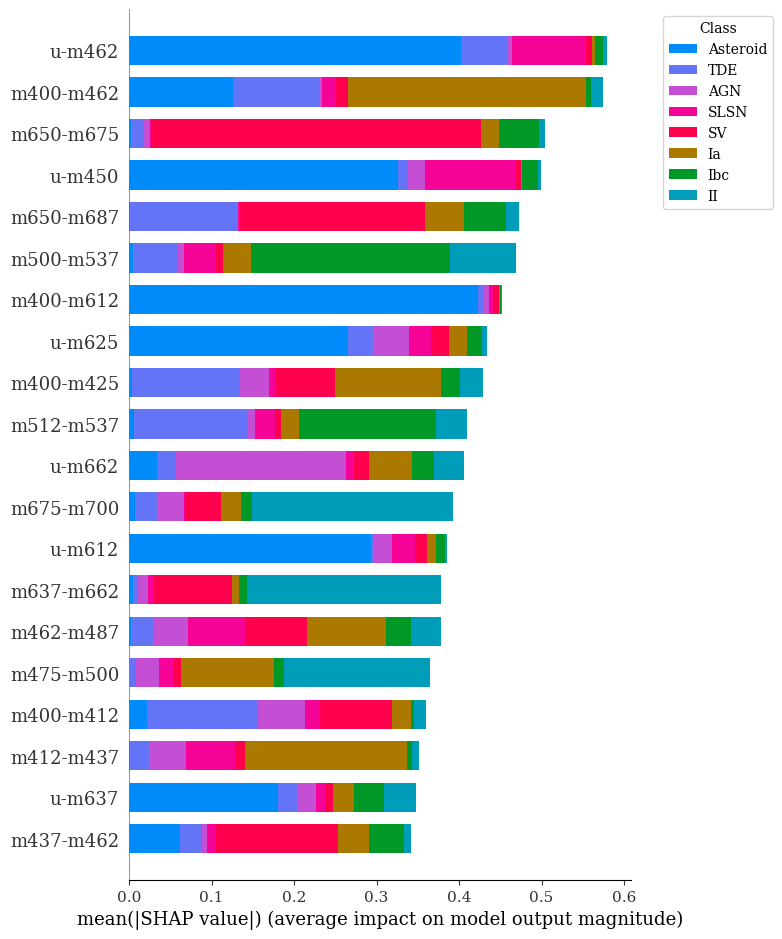

MODEL NAME: 7DT+g


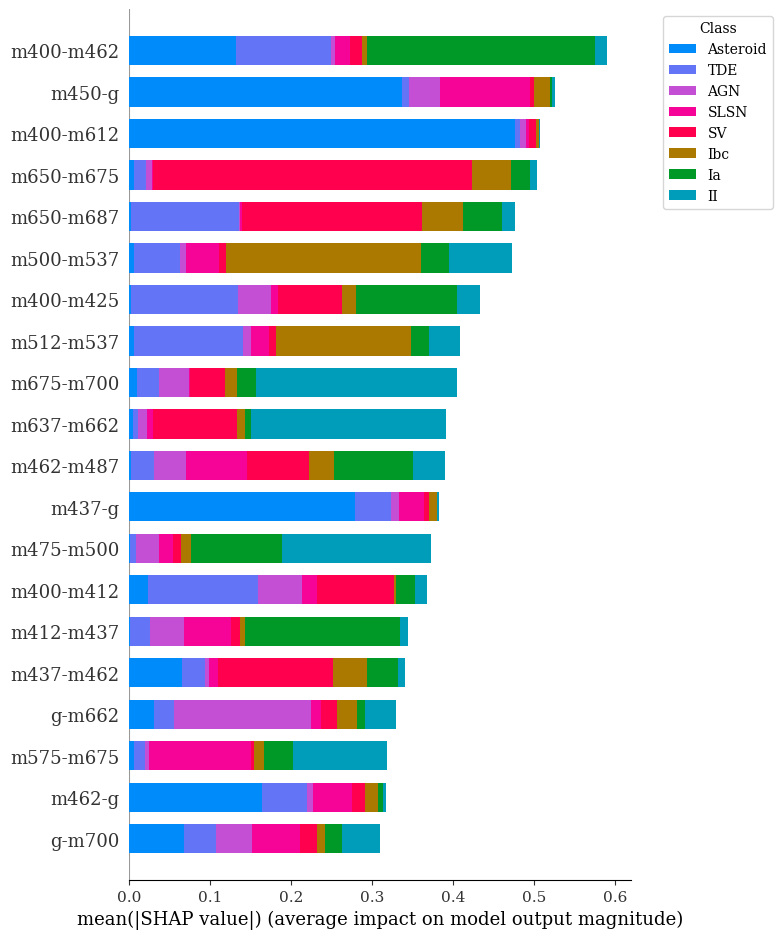

MODEL NAME: 7DT+r


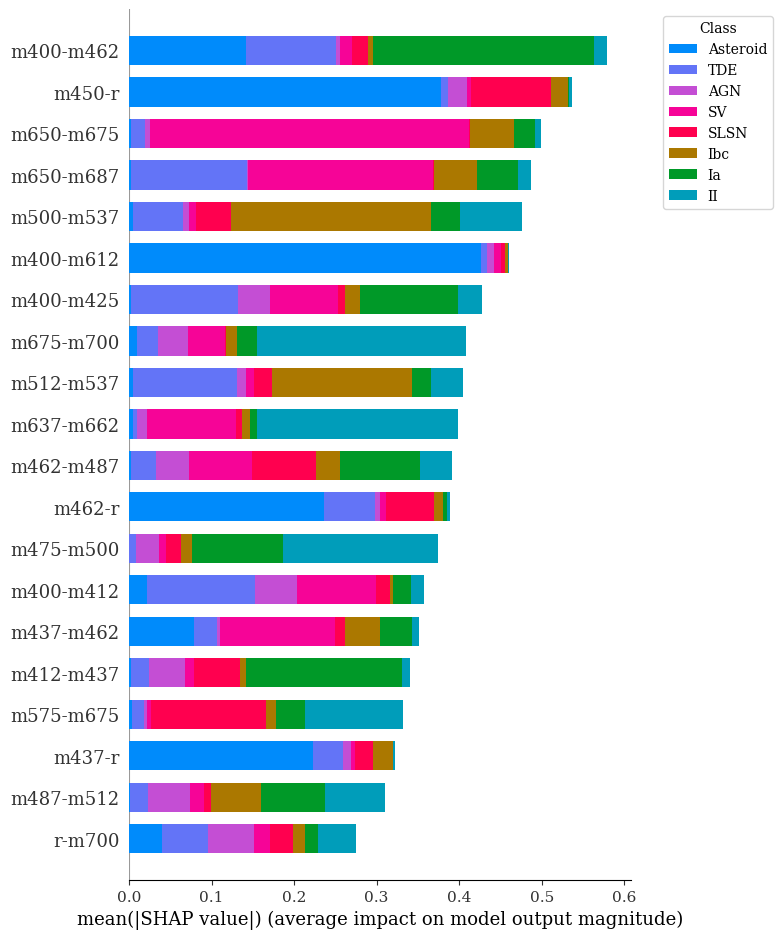

MODEL NAME: 7DT+i


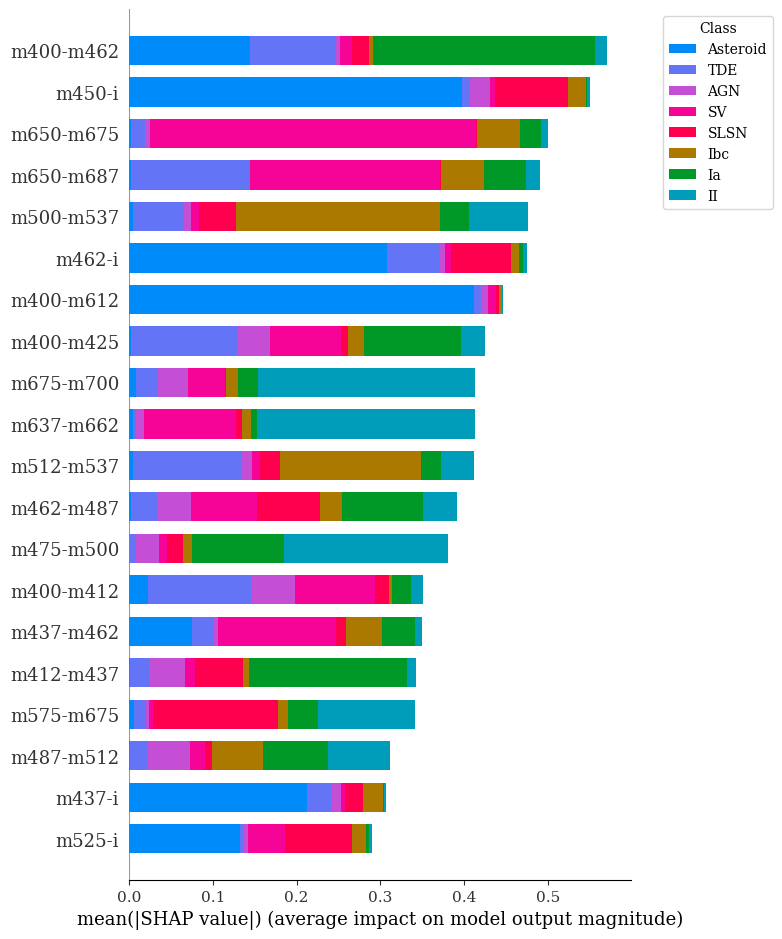

MODEL NAME: 7DT+z


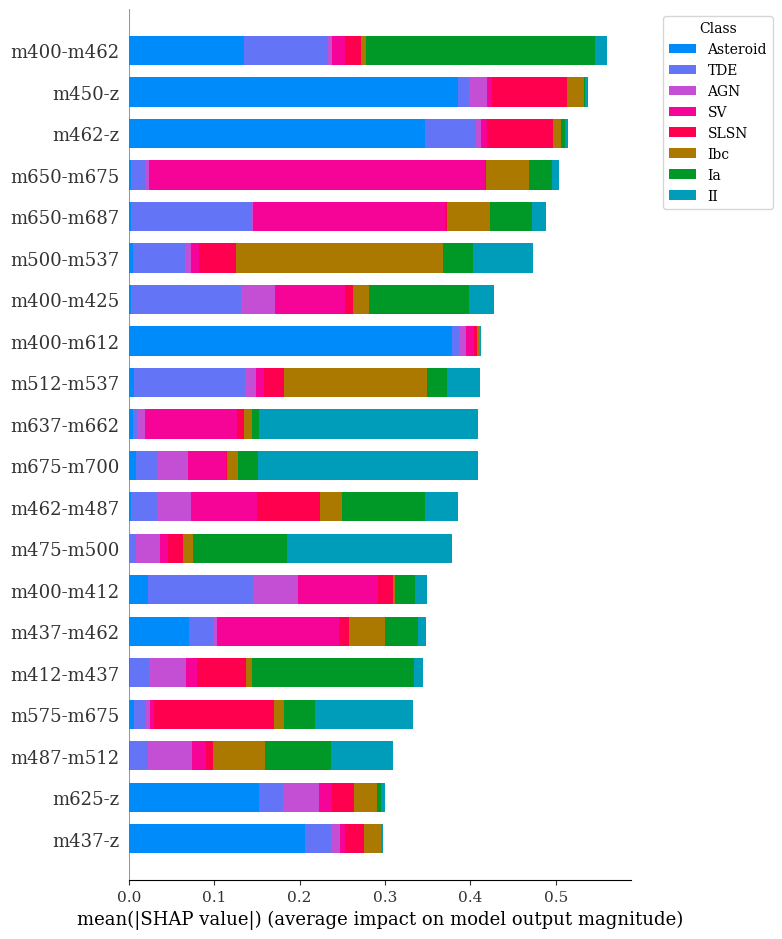

MODEL NAME: 7DT+y


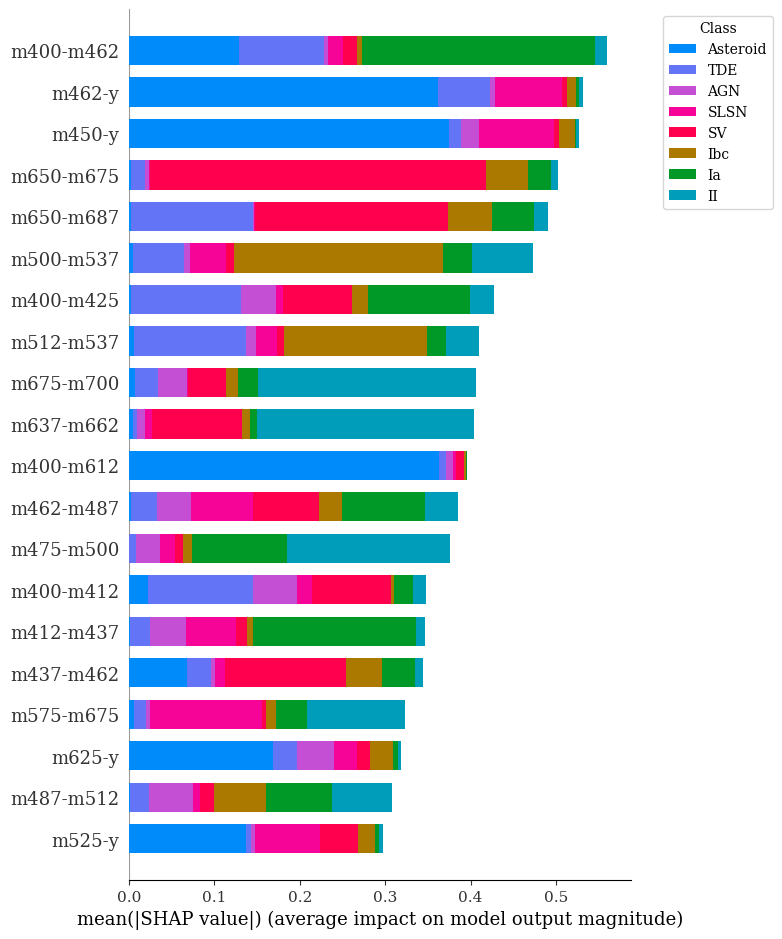

DONE


In [74]:
import shap

# 환경변수로 core 제한 (추가 안정성 확보)
# os.environ["OMP_NUM_THREADS"] = "15"
# os.environ["MKL_NUM_THREADS"] = "15"
# os.environ["TBB_NUM_THREADS"] = "15"

for model_name, pickle_name in model_pickles_dict.items():
    print(f"MODEL NAME: {model_name}")

    info_dict = model_dict[model_name]

    y_pred = info_dict["y_pred"]

    # 데이터 샘플링
    filte = model_name.split("+")[-1]
    features = sub_feature_dict[filte]
    X_sample = X_train[features].sample(n=1000, random_state=42)
    
    # SHAP explainer 계산 (TreeExplainer는 model structure 사용)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer_xgb.shap_values(X_sample)
    importance = compute_importance(shap_values)
    nor_mean_importance = importance / importance.sum()

    # DataFrame
    importance_df = pd.DataFrame({
        'Feature': features,
        'XGBoost': nor_mean_importance,
    }).set_index('Feature')
    
    info_dict['explainer'] = explainer
    info_dict['shap_values'] = shap_values
    info_dict['importance'] = importance
    info_dict['nor_mean_importance'] = nor_mean_importance
    info_dict['importance_df'] = importance_df

    model_dict[model_name] = info_dict
    # plot_type="bar"로 class별 평균 SHAP 시각화
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    
    # 클래스 이름 대체
    class_names = label_encoder.classes_  # 예: ['AGN', 'Asteroid', ..., 'TDE']
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    
    # 'Class 0', 'Class 1', ... → 클래스명으로 변경
    new_labels = [class_names[int(lbl.split()[-1])] for lbl in labels]
    
    # legend 재설정
    ax.legend(handles, new_labels, title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(path_save, f"{model_name}_shap_summary.png"))
    plt.show()
    #

print(f"DONE")

MODEL NAME: 7DT+u
MODEL NAME: 7DT+g
MODEL NAME: 7DT+r
MODEL NAME: 7DT+i
MODEL NAME: 7DT+z
MODEL NAME: 7DT+y


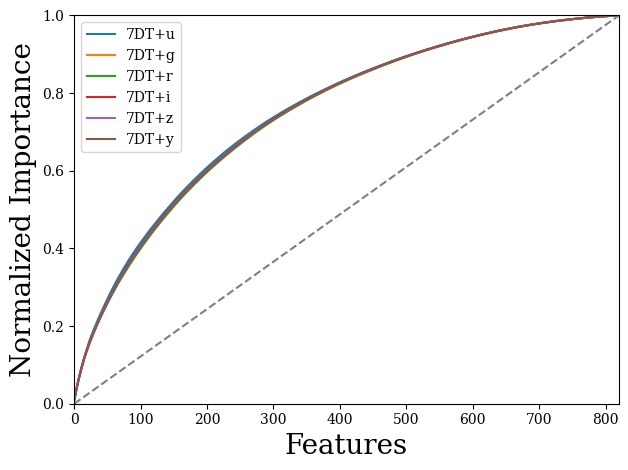

In [69]:
for model_name, pickle_name in model_pickles_dict.items():
    print(f"MODEL NAME: {model_name}")

    info_dict = model_dict[model_name]
    imp_values = info_dict['nor_mean_importance']

    indx_sort = np.argsort(-1*imp_values)
    sorted_nor_mean_imp = imp_values[indx_sort]
    cum_mean_imp = np.cumsum(sorted_nor_mean_imp)
    plt.plot(cum_mean_imp, label=model_name)

plt.plot([0, len(sorted_nor_mean_imp)], [0, 1], ls='--', c='grey')

_ = plt.xlabel("Features")
_ = plt.ylabel("Normalized Importance")
plt.xlim(0, len(sorted_nor_mean_imp))
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.tight_layout()

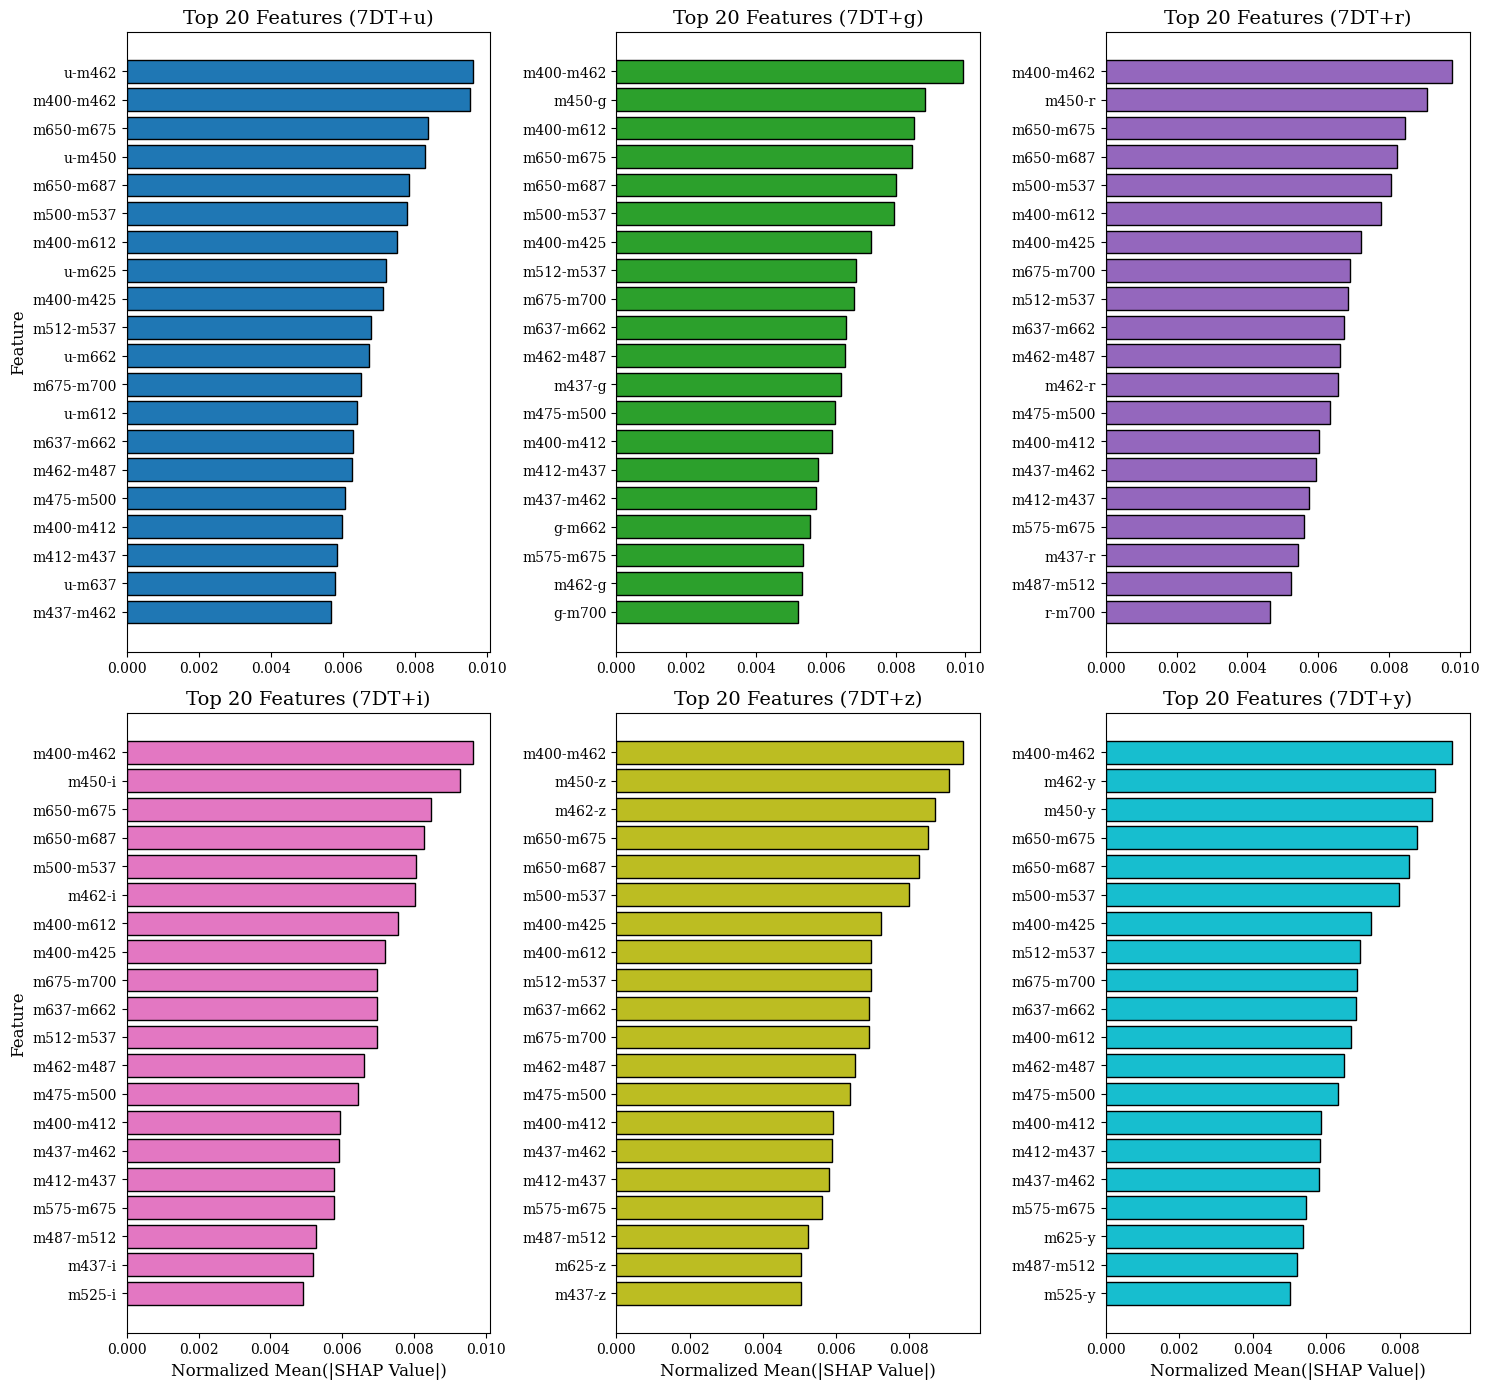

In [75]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 사용할 모델들
# methods = ['XGBoost+g', 'XGBoost+r', 'XGBoost+i']  # 예시: model_dict에 들어있는 키와 일치해야 함abs
methods = [model_name for model_name in model_dict.keys()]
n_methods = len(methods)
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 7 * n_rows), squeeze=False)

# 색상 지정 (e.g., tab10 컬러맵)
colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

# 각 subplot에 feature importance 그리기
for i, model_name in enumerate(methods):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]

    # model_dict에서 해당 importance_df 불러오기
    importance_df = model_dict[model_name]["importance_df"]

    # 상위 20개 feature 선택
    importance_df_sorted = importance_df.sort_values(by='XGBoost', ascending=False).head(20)

    # 수평 막대 그래프
    ax.barh(
        importance_df_sorted.index,
        importance_df_sorted['XGBoost'],
        color=colors[i],
        edgecolor='black'
    )
    ax.invert_yaxis()
    ax.set_title(f"Top 20 Features ({model_name})", fontsize=14)

    if col == 0:
        ax.set_ylabel("Feature", fontsize=12)
    if row == n_rows - 1:
        ax.set_xlabel("Normalized Mean(|SHAP Value|)", fontsize=12)

    ax.tick_params(axis='both', labelsize=10)

# 남는 subplot은 꺼버림
for i in range(len(methods), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()


In [110]:
for model_name in model_dict:
    print(f"Calculating filter-wise score for {model_name}...")
    filte = model_name.split("+")[-1]

    # 필요 데이터 꺼내기
    info = model_dict[model_name]
    nor_mean_importance = info["nor_mean_importance"]
    features = info["importance_df"].index.tolist()

    # Table 초기화
    score_table = Table()
    score_table["feature"] = features
    for filte in MEDIUM_BANDS + [filte]:
        score_table[filte] = [0.0] * len(features)

    # 필터 importance 계산
    for ff, feature in enumerate(score_table["feature"]):
        try:
            filter0, filter1 = feature.split("-")
        except ValueError:
            continue  # color feature가 아닌 경우 (e.g., 단일 mag 등) skip
            
        weight = nor_mean_importance[ff]
        score_table[filter0][ff] += weight
        score_table[filter1][ff] += weight

    # print(score_table['m412'][0])
    # 저장
    model_dict[model_name]["score_table"] = score_table



Calculating filter-wise score for 7DT+u...
Calculating filter-wise score for 7DT+g...
Calculating filter-wise score for 7DT+r...
Calculating filter-wise score for 7DT+i...
Calculating filter-wise score for 7DT+z...
Calculating filter-wise score for 7DT+y...


In [132]:
selected_feature_table= Table()

for model_name in model_dict:
    print(f"Analyzing filter importance for {model_name}...")

    # 필요 데이터 꺼내기
    filte = model_name.split("+")[-1]
    info = model_dict[model_name]
    nor_mean_importance = info["nor_mean_importance"]
    features = info["importance_df"].index.tolist()
    
    score_table = model_dict[model_name]["score_table"]
    filters = score_table.keys()[1:]
    # 필터별 importance 합계 계산
    total_filter_scores = np.array([score_table[filte].sum() for filte in filters])
    
    # 중요도 순으로 정렬된 필터 이름
    sorted_filters = np.array(filters)[np.argsort(-1 * total_filter_scores)]
    top20_filters = sorted_filters[:20]

    selected_med_filters = sorted_filters[1:21]

    top20_filters = sorted_filters[0:21]
    selected_features = []    
    for feature in features:
        part = feature.split("-")
        filter0 = part[0]
        filter1 = part[1]
    
        if (filter0 in top20_filters) & (filter1 in top20_filters):
            selected_features.append(feature)
    print(f"[{model_name}] {len(selected_features)} FILTERS SELECTED AMONG {len(features)}")
    selected_feature_table[model_name] = selected_features
    # print(selected_features)
    
    # 저장
    model_dict[model_name]["total_filter_scores"] = total_filter_scores
    model_dict[model_name]["sorted_filters"] = sorted_filters
    model_dict[model_name]["selected_med_filters"] = selected_med_filters
    model_dict[model_name]["selected_features"] = selected_features

    # 시각화
    # plt.figure(figsize=(10, 4))
    # plt.bar(filters, total_filter_scores, width=0.5)
    # plt.xticks(rotation=90)
    # plt.ylabel("Total Importance")
    # plt.title(f"Filter-wise Importance ({model_name})")
    # plt.tight_layout()
    # plt.savefig(os.path.join(path_save, f"{model_name}_filter_importance.png"))
    # plt.show()

selected_feature_table.write(os.path.join(path_save, "selected_feature_from_top20_filters.csv",))

Analyzing filter importance for 7DT+u...
[7DT+u] 210 FILTERS SELECTED AMONG 820
Analyzing filter importance for 7DT+g...
[7DT+g] 210 FILTERS SELECTED AMONG 820
Analyzing filter importance for 7DT+r...
[7DT+r] 210 FILTERS SELECTED AMONG 820
Analyzing filter importance for 7DT+i...
[7DT+i] 210 FILTERS SELECTED AMONG 820
Analyzing filter importance for 7DT+z...
[7DT+z] 210 FILTERS SELECTED AMONG 820
Analyzing filter importance for 7DT+y...
[7DT+y] 210 FILTERS SELECTED AMONG 820


In [ ]:
stop

In [ ]:
xgb_total_filter_scores = np.array([xgb_score_table[filte].sum() for filte in MEDIUM_BANDS])
#
xgb_sorted_MEDIUM_BANDS = np.array(MEDIUM_BANDS)[np.argsort(-1*xgb_total_filter_scores)]
xgb_top20_filters = xgb_sorted_MEDIUM_BANDS[:20]
xgb_top20_filters
#
plt.figure(figsize=(10, 4))
plt.bar(MEDIUM_BANDS, xgb_total_filter_scores, width=0.5,)
_ = plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.tight_layout()

xgb_top20_filters


In [ ]:
colors = makeSpecColors(len(MEDIUM_BANDS))[::-1]

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.cm as cmx
import numpy as np

# 1. Normalize importance for colormap scaling
norm = plt.Normalize(vmin=xgb_total_filter_scores.min(), vmax=xgb_total_filter_scores.max())
cmap = plt.cm.viridis  # 또는 'plasma', 'coolwarm', 'YlOrRd'

colors_imp = cmap(norm(xgb_total_filter_scores))

# 2. Plot 구성
fig, (ax_rect, ax_bar) = plt.subplots(2, 1, figsize=(12, 5), height_ratios=[0.3, 1], sharex=True)

# 3. 위쪽 색상 사각형 (1x40)
for i, (filter_name, color) in enumerate(zip(MEDIUM_BANDS, colors_imp)):
    ax_rect.add_patch(plt.Rectangle((i - 0.5, 0), 1, 1, color=color))

ax_bar.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
ax_rect.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)

ax_rect.axis('off')

# 4. 아래쪽 Bar plot
# ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color='steelblue', width=0.8)
ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color=colors, width=0.8, edgecolor='black')
ax_bar.set_xticks(np.arange(len(MEDIUM_BANDS)))
ax_bar.set_xticklabels(MEDIUM_BANDS, rotation=90)
ax_bar.set_ylabel("Importance")
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Tight layout
plt.tight_layout()
plt.show()

## Class-wise Feature importance 

In [ ]:
class_names = ['AGN', 'Asteroid', 'II', 'Ia', 'Ibc', 'SLSN', 'SV', 'TDE']

for target_class_name in class_names:
    importance_cat_cls = compute_importance(shap_values_cat, target_class=target_class_name, class_names=class_names)
    importance_xgb_cls = compute_importance(shap_values_xgb, target_class=target_class_name, class_names=class_names)
    importance_lgb_cls = compute_importance(shap_values_lgb, target_class=target_class_name, class_names=class_names)
    
    # normalize
    importance_cat_cls /= importance_cat_cls.sum()
    importance_xgb_cls /= importance_xgb_cls.sum()
    importance_lgb_cls /= importance_lgb_cls.sum()
    
    importance_df_cls = pd.DataFrame({
        "Feature": feature_names,
        "CatBoost": importance_cat_cls,
        "XGBoost": importance_xgb_cls,
        "LightGBM": importance_lgb_cls,
    }).set_index("Feature")
    
    
    # 예시: 상위 20개 feature 시각화
    n_methods = len(methods)
    colors_bar = plt.cm.tab10(np.linspace(0, 1, n_methods))
    
    fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 6), squeeze=False)
    
    for i, met in enumerate(methods):
        ax = axes[0][i]
        df_sorted = importance_df_cls.sort_values(by=met, ascending=False).head(20)
        ax.barh(df_sorted.index, df_sorted[met], color=colors_bar[i], edgecolor='black')
        ax.invert_yaxis()
        ax.set_title(f"{met} - {target_class_name}", fontsize=14)
        ax.set_xlabel("Normalized SHAP Importance")
        ax.tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    plt.show()

    # - - - - -
    
    xgb_score_table = feature_score_table.copy()
    
    for ff, feature in enumerate(xgb_score_table['feature']):
    
        weight = importance_xgb_cls[ff]
    
        filter0 = feature.split('-')[0]
        filter1 = feature.split('-')[1]
    
        xgb_score_table[filter0][ff] += weight
        xgb_score_table[filter1][ff] += weight
    
    
    xgb_total_filter_scores = np.array([xgb_score_table[filte].sum() for filte in MEDIUM_BANDS])
    #
    xgb_sorted_MEDIUM_BANDS = np.array(MEDIUM_BANDS)[np.argsort(-1*xgb_total_filter_scores)]
    xgb_top20_filters = xgb_sorted_MEDIUM_BANDS[:20]

    
    # 1. Normalize importance for colormap scaling
    norm = plt.Normalize(vmin=xgb_total_filter_scores.min(), vmax=xgb_total_filter_scores.max())
    cmap = plt.cm.viridis  # 또는 'plasma', 'coolwarm', 'YlOrRd'
    
    colors_imp = cmap(norm(xgb_total_filter_scores))
    
    # 2. Plot 구성
    fig, (ax_rect, ax_bar) = plt.subplots(2, 1, figsize=(12, 5), height_ratios=[0.3, 1], sharex=True)
    
    # 3. 위쪽 색상 사각형 (1x40)
    for i, (filter_name, color) in enumerate(zip(MEDIUM_BANDS, colors_imp)):
        ax_rect.add_patch(plt.Rectangle((i - 0.5, 0), 1, 1, color=color))
    
    ax_bar.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
    ax_rect.set_xlim(-0.5, len(MEDIUM_BANDS) - 0.5)
    
    ax_rect.axis('off')
    
    # 4. 아래쪽 Bar plot
    # ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color='steelblue', width=0.8)
    ax_bar.bar(np.arange(len(MEDIUM_BANDS)), xgb_total_filter_scores, color=colors, width=0.8, edgecolor='black')
    ax_bar.set_xticks(np.arange(len(MEDIUM_BANDS)))
    ax_bar.set_xticklabels(MEDIUM_BANDS, rotation=90)
    ax_bar.set_ylabel("Importance")
    ax_bar.grid(axis='y', linestyle='--', alpha=0.5)
    ax_bar.set_title(f"{target_class_name}", fontsize=14)
    
    # 5. Tight layout
    plt.tight_layout()
    plt.savefig(f"{path_save}/xgboost_{target_class_name}_filter_importance.png")
    plt.show()
    # break 

## Sensitivity vs Feature Importance 

In [ ]:
# 7DT Setting
sys.path.append('..')
from simulator.helper import *
from simulator.sdtpy import *
register_custom_filters_on_speclite('../simulator')

#	Exposure Time [s]
sdt = SevenDT()
sdt.echo_optics()
filterset = sdt.generate_filterset(bandmin=BANDMIN, bandmax=BANDMAX, bandwidth=BANDWIDTH, bandstep=BANDSTEP, bandrsp=BANDRSP, lammin=LAMMIN, lammax=LAMMAX, lamres=LAMRES)
T_qe = sdt.get_CMOS_IMX455_QE()
sdt.get_optics()
s = sdt.get_sky()
sdt.smooth_sky()
totrsptbl = sdt.calculate_response()
Npix_ptsrc, Narcsec_ptsrc = sdt.get_phot_aperture(exptime=EXPTIME_SINGLE, fwhm_seeing=SEEING, optfactor=EFF_FACTOR, verbose=False)
depthtbl = sdt.get_depth_table(Nsigma=5)
sdt.get_speclite()

In [ ]:
totrsptbl[:3]

In [ ]:
rsp_arr = []

for filte in np.unique(totrsptbl['name']):
    rsp = totrsptbl['response'][totrsptbl['name'] == filte]
    max_rsp = np.max(rsp)
    # print(filtername, max_rsp)
    rsp_arr.append(max_rsp)

rsp_arr = np.array(rsp_arr)

In [ ]:
total_scores

In [ ]:
colors = makeSpecColors(len(MEDIUM_BANDS), palette='Spectral')[::-1]

plt.scatter(rsp_arr, xgb_total_filter_scores, marker='o', c=colors, ec='k')

score_threshold = 0.05
resp_threshold = 0.9
for filte, resp_value, score in zip(MEDIUM_BANDS, rsp_arr, xgb_total_filter_scores):
    if (score > score_threshold) & (resp_value < resp_threshold):
        plt.text(resp_value, score, s=filte)

plt.xlabel("Maximum Response [%]")
plt.ylabel("Importance")

# Result Save

In [ ]:
path_final_models = os.path.join(MODEL, "final_normal_class_model")
os.makedirs(path_final_models, exist_ok=True)

In [ ]:
# CatBoost
cat_model.save_model(os.path.join(path_final_models, "catboost_model.cbm"))

# XGBoost
xgb_model.save_model(os.path.join(path_final_models, "xgboost_model.json"))  # or .bst

# LightGBM
import joblib
joblib.dump(lgbm_model, os.path.join(path_final_models, "lightgbm_model.pkl"))

In [ ]:
import numpy as np
import joblib
import shap
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 불러오기
def load_ensemble_models(cat_path, xgb_path, lgb_path):
    cat = CatBoostClassifier()
    cat.load_model(cat_path)

    xgb = XGBClassifier()
    xgb.load_model(xgb_path)

    lgb = joblib.load(lgb_path)

    return cat, xgb, lgb

# 예측 함수 정의
def ensemble_predict(X, cat, xgb, lgb, weights=None):
    """
    Args:
        X: input features (DataFrame or ndarray)
        cat, xgb, lgb: trained model instances
        weights: None for soft voting, or list like [w_cat, w_xgb, w_lgb]
    Returns:
        pred_class: final predicted class index
        pred_probs: averaged or weighted probability
    """
    p_cat = cat.predict_proba(X)
    p_xgb = xgb.predict_proba(X)
    p_lgb = lgb.predict_proba(X)

    if weights is None:
        # soft voting
        probs = (p_cat + p_xgb + p_lgb) / 3
    else:
        probs = (
            p_cat * weights[0] +
            p_xgb * weights[1] +
            p_lgb * weights[2]
        )

    pred_class = np.argmax(probs, axis=1)
    return pred_class, probs

In [ ]:
# Load models
cat, xgb, lgb = load_ensemble_models(
    os.path.join(path_final_models, "catboost_model.cbm"),
    os.path.join(path_final_models, "xgboost_model.json"),
    os.path.join(path_final_models, "lightgbm_model.pkl"),
)

# Predict
y_pred, y_probs = ensemble_predict(X_test, cat, xgb, lgb, weights=best_weights)

In [ ]:
import json
json.dump({"weights": [val for val in best_weights]}, open(os.path.join(path_final_models, "ensemble_weights.json"), "w"))